In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use('sci.mplstyle')

In [2]:
def luu_file(filename, u, err, L, k):
    n = u.shape[0]

    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"### Ket qua tai vong lap {k}\n")
        file.write(f"### Max error = {np.max(err):.6e}\n")
        file.write("#" * 80 + "\n")
        file.write(f"### {'x':>15s} {'y':>15s} {'V':>15s} {'Error':>15s}\n")

        for i in range(n):
            for j in range(n):
                x = i * L / (n - 1)
                y = j * L / (n - 1)
                file.write(f"    {x:15.6f} {y:15.6f} {u[i,j]:15.6f} {err[i,j]:15.6e}\n")
            file.write("\n")

In [3]:
# u: mang dieu kien bien n x n 
# L: chieu dai cua vung can tinh
# N_max: so vong lap toi da cua Gauss
# err_max: sai so de hoi tu
# start va end: chi so bat dau va ket thuc theo chieu ngang cua thanh theo phuong ngang
# thanh_o_tren: chi so j cua thanh tren
# thanh_o_duoi: chi so j cua thanh duoi


def hamtinh_laplace_gauss_seidel_codieukien2thanh(u, L, start, end, thanh_o_tren , thanh_o_duoi, N_max=100000, err_max=1e-6, filename="bai3b"):
    global h, rho, x, y
    n = u.shape[0]  # kich thuoc luoi n x n

    for k in range(N_max):
        u_old = u.copy()  # luu nghiem cua vong lap truoc

        # cap nhat cac diem ben trong theo cong thuc Gauss-Seidel
        for i in range(1, n - 1):
            for j in range(1, n - 1):
                if start <= i < end and (thanh_o_tren - 3 <= j <= thanh_o_tren + 3 or thanh_o_duoi -3 <= j <= thanh_o_duoi + 3):
                    # co nghia la neu ma i nam trong khoang thanh do, j cung nam trong khoang thanh do thi bo qua
                    # modify cho bai 3b la dung thanh_o_tren + 3 va -3 
                    continue
                u[i, j] = 0.25 * (
                    u[i + 1, j]  # diem ben phai
                    + u[i - 1, j]  # diem ben trai
                    + u[i, j + 1]  # diem ben tren
                    + u[i, j - 1]  # diem ben duoi
                    #+ h**2 * np.pi * rho(x[i], y[j]) 

                )
        # khi dang tinh u[i,j] thi u[i+1, j] va u[i, j + 1] la chua cap nhat nen no la old
        # trong khi do u[i-1, j] va u[i, j - 1] la chap nhat roi nen no la new

        # tinh sai so giua hai lan lap lien tiep
        err = np.abs(u - u_old)

        # lay sai so lon nhat tren toan bo luoi
        max_err = np.max(err)

        # kiem tra dieu kien hoi tu
        if max_err < err_max:
            print(f"Gauss-Seidel hoi tu sau {k} vong lap, max_err = {max_err:.3e}")

            # luu nghiem va sai so ra file
            luu_file(filename + "_gs_result.txt", u, err, L, k)

            return u

    # truong hop khong hoi tu sau N_max vong lap
    print(f"Gauss-Seidel khong hoi tu sau {N_max} vong lap, max_err = {max_err:.3e}")
    # luu ket qua cuoi cung ra file
    luu_file(filename + "_gs_result_khonghoitu.txt", u, err, L, N_max)

    return u

In [4]:
def dieukienbien_bai3b(n, u_bien, u_thap, u_cao, chieudai, chieurong, L):

    #length nhap vo la chieu ngang/boundary ngang, width nhap vo la chieu doc/boundary doc

    u = np.zeros((n, n), dtype=float)

    # u[i,0] = bottom
    for i in range(n):
        u[i, 0] = u_bien

    # u[0,j] = left
    for j in range(n):
        u[0, j] = u_bien

    # u[n-1,j] = right
    for j in range(n):
        u[n-1, j] = u_bien

    # u[i,n-1] = top
    for i in range(n):
        u[i, n-1] = u_bien

    # Thanh co chieu ngang tu (n-chieudai)/2 den (n+chieudai)/2, chieu doc nam o n+(chieurong/2) co dien ap u_cao
    # Thanh co chieu ngang tu (n-chieudai)/2 den (n+chieudai)/2, chieu doc nam o n-(chieurong/2) co dien ap u_thap

    n_chieudai  = int(chieudai  / L * (n - 1))   # 50/100 * 99 = 49
    n_chieurong = int(chieurong / L * (n - 1))   # 30/100 * 99 = 29

    n_center = n // 2
    thanh_o_tren = n_center + n_chieurong // 2
    thanh_o_duoi = n_center - n_chieurong // 2

    start  = (n-n_chieudai) // 2
    end = start + n_chieudai

# modify cho bai 3b, tu thanh - 3 > thanh + 3 la 6 khoang

    for i in range(start, end):
        for j in range(thanh_o_tren-3,thanh_o_tren+ 3 +1):
            u[i, j] = u_cao

    for i in range(start, end):
        for j in range(thanh_o_duoi-3,thanh_o_duoi+ 3 +1): # cong 1 len vi no se dem toi +3 thoi
            u[i, j] = u_thap

    return u, start, end, thanh_o_tren, thanh_o_duoi

In [5]:
def doc_file_ketqua(filename): #dung de doc file ket qua
    x, y, V, err = np.loadtxt(filename, unpack=True, comments="#")

    # Lay so diem luoi tu file

    # unique co nghia la so day x ma co so khac nhau
    x_unique = np.unique(x)
    y_unique = np.unique(y)

    # lay len se ra duoc so diem x va y khac nhau -> luoi
    nx = len(x_unique)
    ny = len(y_unique)

    print("File:", filename)
    print("nx =", nx)
    print("ny =", ny)
    print("So diem trong file =", len(x))
    print("nx * ny =", nx * ny)

    # Neu file luu theo for i roi luu for j
    X = x.reshape(nx, ny)
    Y = y.reshape(nx, ny)
    V2D = V.reshape(nx, ny)
    err2D = err.reshape(nx, ny)

    return x_unique, y_unique, X, Y, V2D, err2D

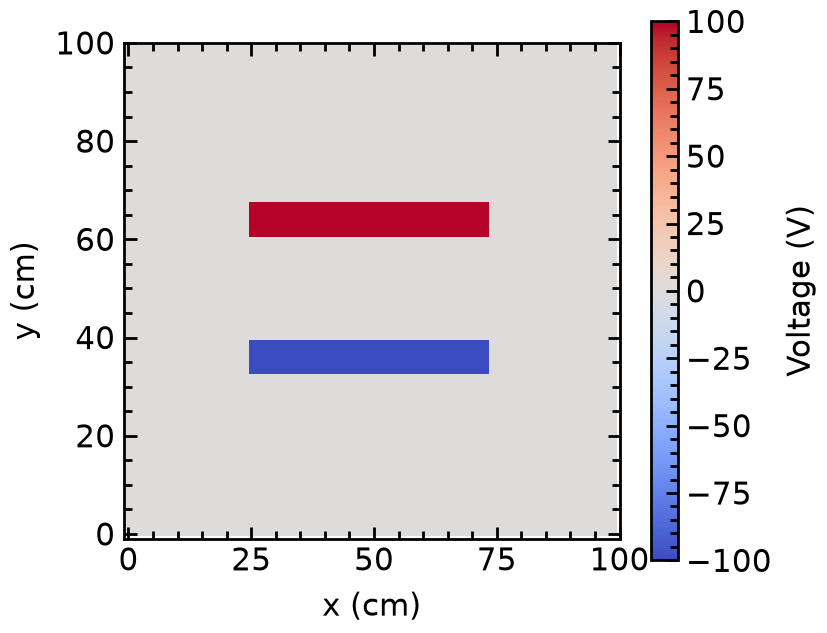

In [6]:
L = 100
n = 100
u_bien = 0
u_thap = -100
u_cao = 100
chieudai = 50
chieurong = 30


# Kiem tra dieu kien bien 
u_bien_bai3b, start_bai3b, end_bai3b, thanh_o_tren_bai3b, thanh_o_duoi_bai3b = dieukienbien_bai3b(n, u_bien, u_thap, u_cao, chieudai, chieurong, L)
plt.figure(figsize=(8, 7))
plt.imshow(u_bien_bai3b.T, origin='lower', cmap='coolwarm')
plt.xlim(-1, 100)
plt.ylim(-1, 100)
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.colorbar(label='Voltage (V)')
plt.show()
N_max = 100000
err_max = 1e-6

In [7]:
u_result_bai3b = hamtinh_laplace_gauss_seidel_codieukien2thanh(u_bien_bai3b, 
                                                        L, start=start_bai3b, 
                                                        end=end_bai3b, 
                                                        thanh_o_tren=thanh_o_tren_bai3b, 
                                                        thanh_o_duoi=thanh_o_duoi_bai3b,
                                                        N_max=100000, 
                                                        err_max=1e-6, 
                                                        filename="bai3b")

Gauss-Seidel hoi tu sau 2635 vong lap, max_err = 9.969e-07


Locator attempting to generate 1001 ticks ([-100.0, ..., 100.0]), which exceeds Locator.MAXTICKS (1000).


File: bai3b_gs_result.txt
nx = 100
ny = 100
So diem trong file = 10000
nx * ny = 10000


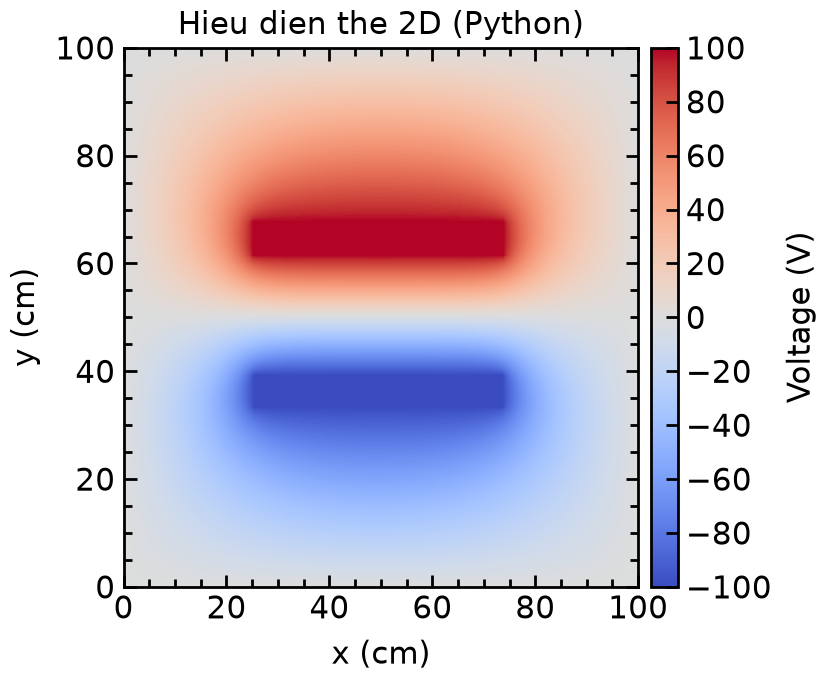

In [8]:
x_unique_gs_bai3b, y_unique_gs_bai3b, X_gs_bai3b, Y_gs_bai3b, V2D_gs_bai3b, err2D_gs_bai3b =  doc_file_ketqua("bai3b_gs_result.txt")


#norm = mcolors.Normalize(vmin=-100, vmax=100)

plt.figure(figsize=(8, 7))
plt.contourf(X_gs_bai3b, Y_gs_bai3b, V2D_gs_bai3b, levels=1000, cmap='coolwarm')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title("Hieu dien the 2D (Python)")
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
cb = plt.colorbar(label='Voltage (V)', orientation='vertical', pad=0.02)

cb.set_ticks(np.arange(-100, 101, 20))
plt.savefig("BT2-PDE-Thetinhdien-bai3b-gs.png", dpi=300)
plt.show()

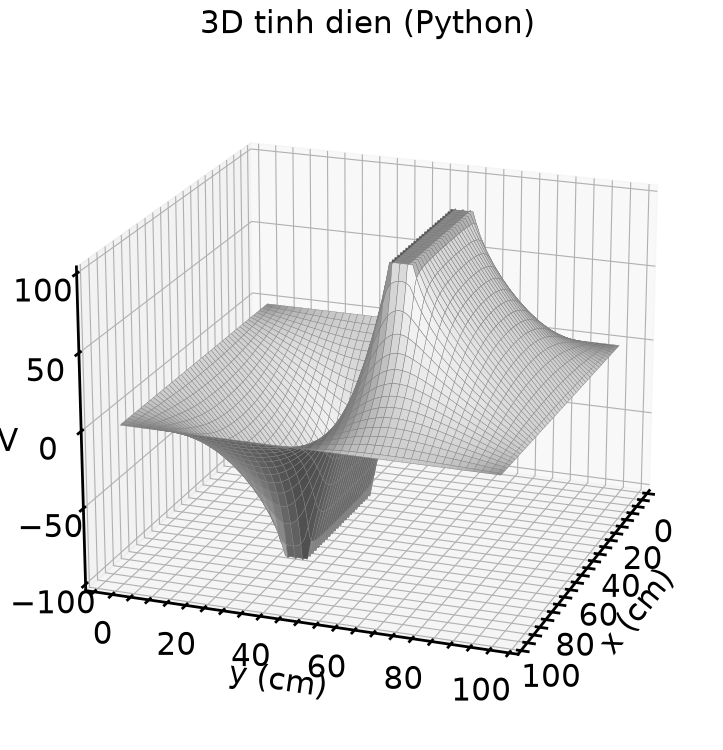

In [9]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

X_gs_bai3b_ve, Y_gs_bai3b_ve = np.meshgrid(X_gs_bai3b, Y_gs_bai3b) # Gia su neu nhu khong chung shape la khong ve duoc

ax.plot_surface(X_gs_bai3b, Y_gs_bai3b, V2D_gs_bai3b, color='white', edgecolor='gray', linewidth=0.3)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('V')
ax.set_title("3D tinh dien (Python)")
ax.view_init(elev=20, azim=20)
plt.savefig("BT3b-PDE-Thetinhdien-bai3b-gs-3D.png", dpi=300)
plt.show()